<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [ ]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 1. Definición del problema y 2. Estadística descriptiva
El objetivo es predecir el valor medio de las casas (`target`) basándonos en características geográficas y demográficas.

In [51]:
# 2. Estadística descriptiva
display(housing.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 3. Visualización descriptiva
Analizamos la correlación entre variables.

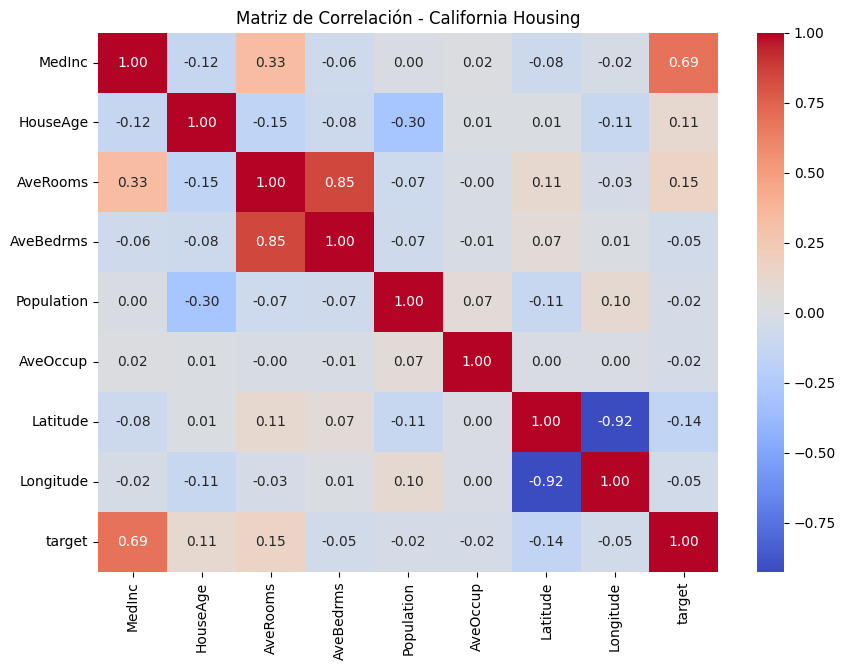

In [52]:
plt.figure(figsize=(10, 7))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - California Housing')
plt.show()

### 4. Preprocesamiento
Dividimos los datos en entrenamiento y prueba, y escalamos las características.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir X e y
X_reg = housing.drop('target', axis=1)
y_reg = housing['target']

# Dividir datos
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Escalar datos
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

print(f"Conjunto entrenamiento: {X_train_reg_scaled.shape}")
print(f"Conjunto prueba: {X_test_reg_scaled.shape}")

Conjunto entrenamiento: (16512, 8)
Conjunto prueba: (4128, 8)


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# 5. Selección de modelos
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=10, random_state=42),
    "KNN Regressor": KNeighborsRegressor()
}

results_list = []

for name, model in models.items():
    # Entrenar
    model.fit(X_train_reg_scaled, y_train_reg)
    # Predecir
    y_hat = model.predict(X_test_reg_scaled)
    # Calcular métricas
    df_temp = pd.DataFrame({'y': y_test_reg, 'yhat': y_hat})
    metrics = regression_metrics(df_temp)
    metrics.index = [name]
    results_list.append(metrics)

# 6. Métricas y análisis de resultados
all_reg_metrics = pd.concat(results_list)
display(all_reg_metrics.sort_values(by='rmse'))

,mae,mse,rmse,mape,smape
Random Forest,0.3489,0.2836,0.5326,20.0121,0.3335
KNN Regressor,0.4462,0.4324,0.6576,24.6681,0.3957
Decision Tree,0.4539,0.4940,0.7028,24.8768,0.3984
Linear Regression,0.5332,0.5559,0.7456,31.9522,0.4843


### 7. Visualización de resultados del modelo
Graficaremos la relación entre el valor real y la predicción del mejor modelo (Random Forest).

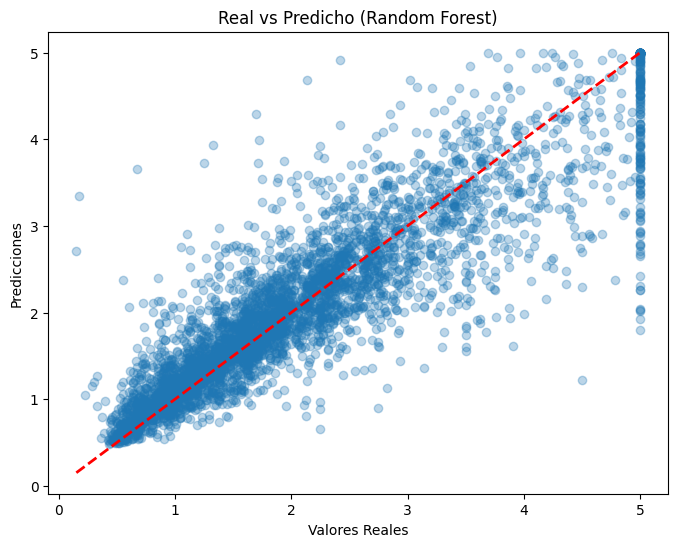

In [55]:
best_model = RandomForestRegressor(n_estimators=10, random_state=42)
best_model.fit(X_train_reg_scaled, y_train_reg)
y_pred_final = best_model.predict(X_test_reg_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_final, alpha=0.3)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (Random Forest)')
plt.show()

### 8. Conclusiones de Regresión
1. El modelo **Random Forest** presentó el mejor desempeño con el menor RMSE.
2. Existe una correlación fuerte entre el ingreso medio (`MedInc`) y el valor de la vivienda.
3. El escalado de datos fue fundamental para modelos como KNN.

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

In [ ]:
# informacion de las columnas
digits_dict.keys()

In [ ]:
# informacion del target
digits_dict["target"]

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [ ]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [56]:
# Ejercicio 1: Análisis exploratorio
print(f"Distribución de clases:\n{digits['target'].value_counts().sort_index()}")
print("\nInformación del DataFrame:")
display(digits.info())
print("\nEstadísticas descriptivas básicas:")
display(digits.describe())
# Los datos son enteros entre 0 y 16 (escala de grises) y no hay valores nulos.

Distribución de clases:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 18  c18     1797 

None


Estadísticas descriptivas básicas:


,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [ ]:
digits_dict["images"][0]

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

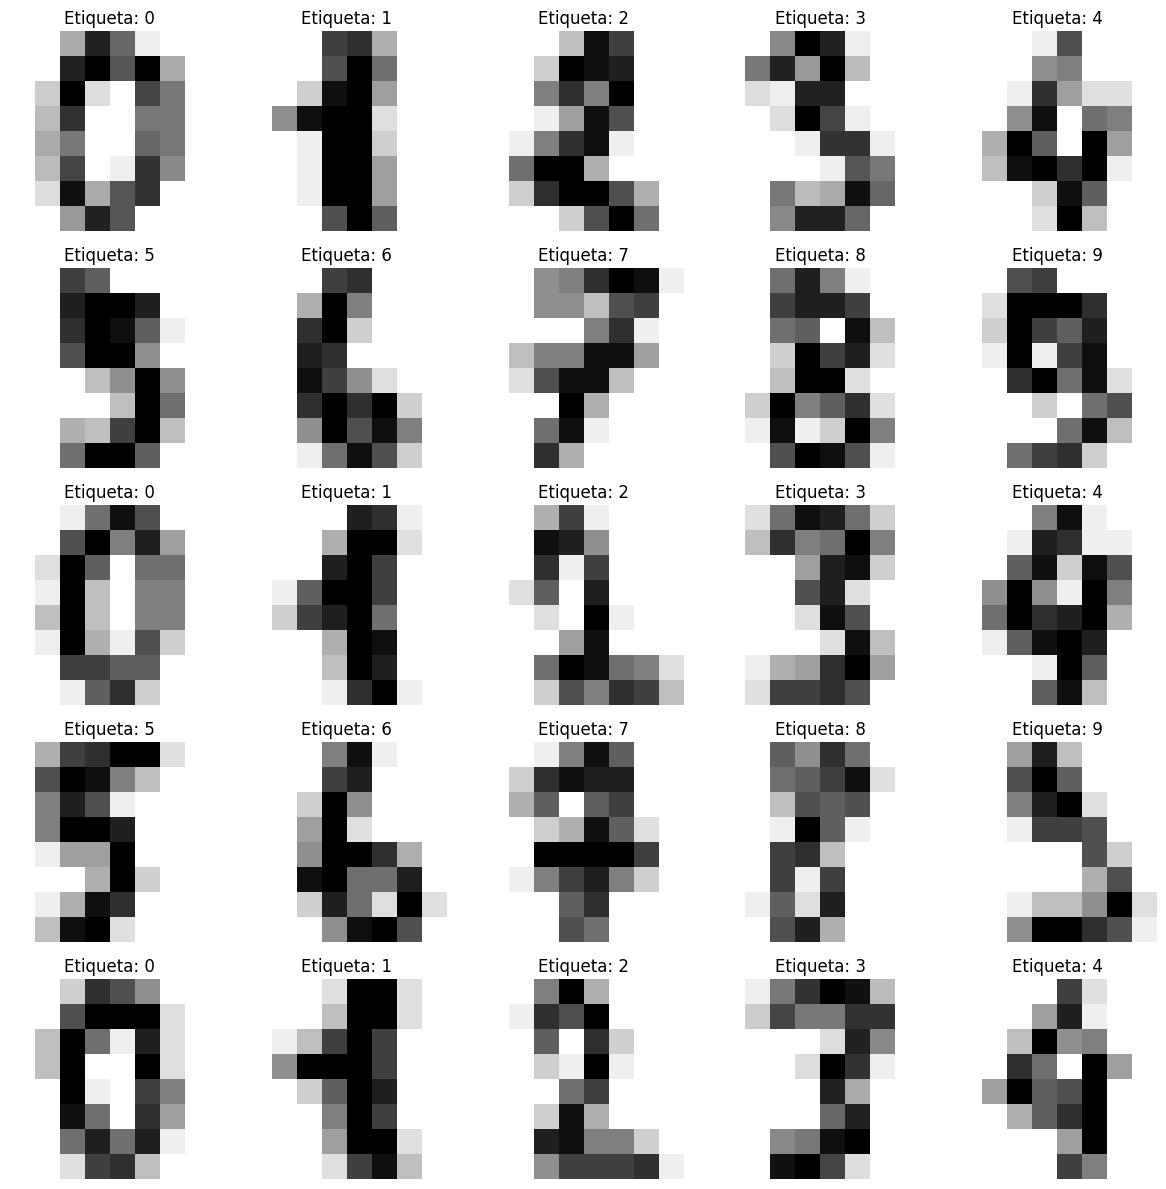

In [57]:
# Ejercicio 2: Visualización
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i in range(nx * ny):
    img = digits_dict["images"][i]
    label = digits_dict["target"][i]
    row, col = divmod(i, ny)
    axs[row, col].imshow(img, cmap='gray_r')
    axs[row, col].set_title(f'Etiqueta: {label}')
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


### Nota sobre el Ejercicio 3
El desarrollo del Ejercicio 3 se encuentra en la siguiente celda de código, donde se instancian los modelos, se calculan las métricas (Accuracy, Precision, Recall, F1) y se generan las matrices de confusión para Logistic Regression, KNN y SVM.

In [ ]:
# features, target

X = digits.drop(columns="target").values
y = digits["target"].values

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

Largo entrenamiento: 1437
Largo testeo: 360


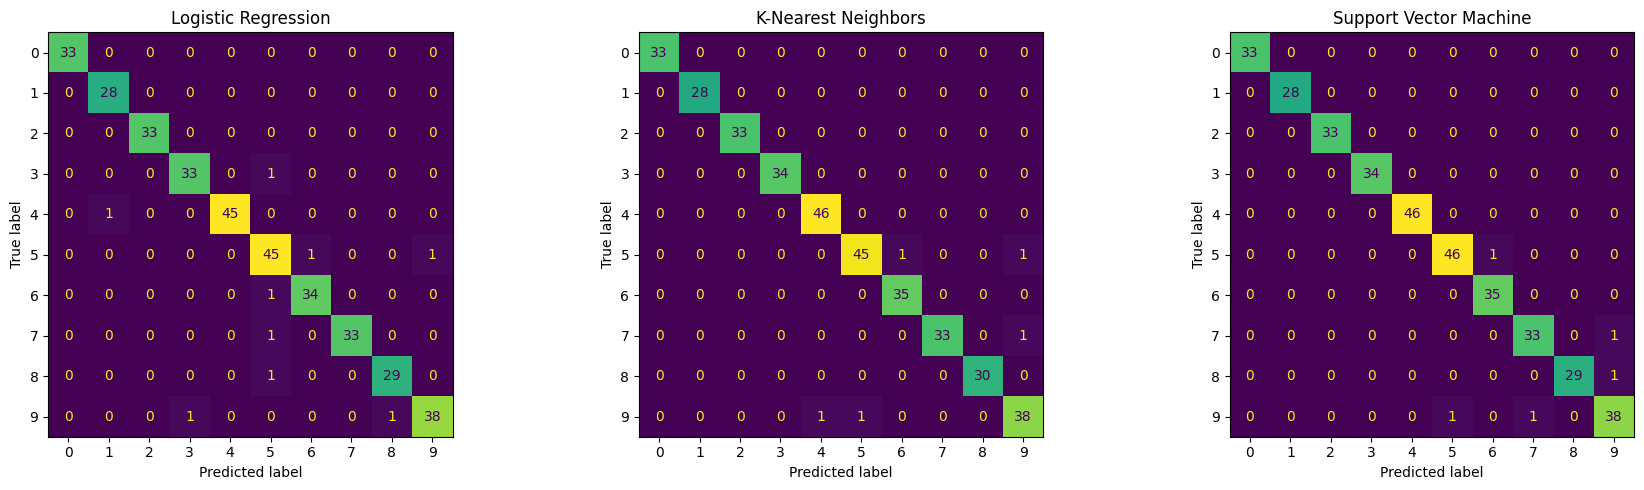

,Accuracy,Precision,Recall,F1-score,Time (s)
Model,,,,,
Logistic Regression,0.975000,0.976693,0.976498,0.976475,3.419188
K-Nearest Neighbors,0.986111,0.987921,0.987804,0.987798,0.005137
Support Vector Machine,0.986111,0.987153,0.986598,0.986828,0.343985


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import time

# 1. Train-test split
X_clf = digits.drop(columns='target')
y_clf = digits['target']
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Largo entrenamiento: {len(X_train_clf)}")
print(f"Largo testeo: {len(X_test_clf)}")

# 2. Instanciar y entrenar modelos
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True)
}

clf_metrics_list = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(clf_models.items()):
    start_time = time.time()
    model.fit(X_train_clf, y_train_clf)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_clf)

    # Métricas
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average='macro')
    rec = recall_score(y_test_clf, y_pred, average='macro')
    f1 = f1_score(y_test_clf, y_pred, average='macro')

    clf_metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Time (s)": train_time
    })

    # Matriz de Confusión
    cm = confusion_matrix(y_test_clf, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"{name}")

plt.tight_layout()
plt.show()

# Comparación de métricas
all_clf_metrics = pd.DataFrame(clf_metrics_list).set_index("Model")
display(all_clf_metrics)

--- Validación Ejercicio 3 ---
Largo entrenamiento: 1437
Largo testeo: 360


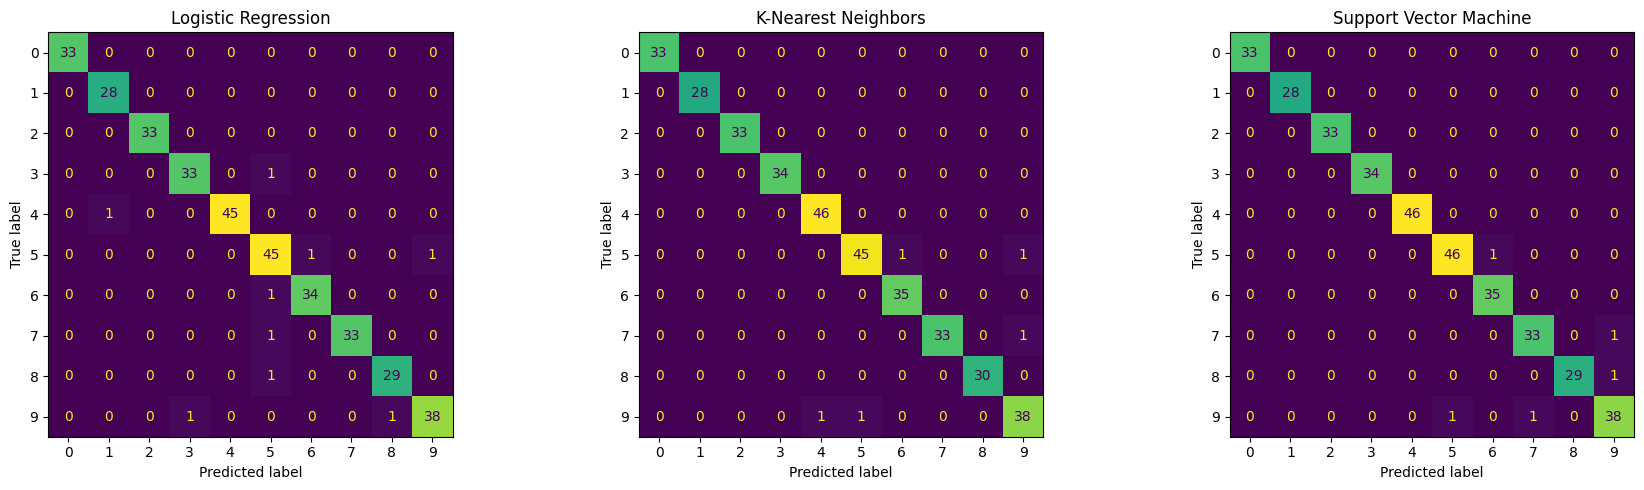

,Accuracy,Precision,Recall,F1-score,Time (s)
Model,,,,,
Logistic Regression,0.975000,0.976693,0.976498,0.976475,0.984200
K-Nearest Neighbors,0.986111,0.987921,0.987804,0.987798,0.003542
Support Vector Machine,0.986111,0.987153,0.986598,0.986828,0.302871


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparación de datos
X_clf = digits.drop(columns='target')
y_clf = digits['target']
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"--- Validación Ejercicio 3 ---")
print(f"Largo entrenamiento: {len(X_train_clf)}")
print(f"Largo testeo: {len(X_test_clf)}")

# 2. Modelos
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True)
}

clf_metrics_list = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(clf_models.items()):
    start_time = time.time()
    model.fit(X_train_clf, y_train_clf)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_clf)

    # Cálculo de Métricas
    clf_metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred, average='macro'),
        "Recall": recall_score(y_test_clf, y_pred, average='macro'),
        "F1-score": f1_score(y_test_clf, y_pred, average='macro'),
        "Time (s)": train_time
    })

    # Visualización Matriz
    cm = confusion_matrix(y_test_clf, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"{name}")

plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
display(pd.DataFrame(clf_metrics_list).set_index("Model"))

### Ejercicio 4: Curva AUC–ROC

Interpretación del gráfico: El área bajo la curva (AUC) para casi todas las clases es cercana a 1.00, lo que indica que el modelo **SVM** tiene una capacidad casi perfecta para distinguir entre los diferentes dígitos. La clase 9 muestra una ligera desviación mínima, coherente con las confusiones visuales típicas.

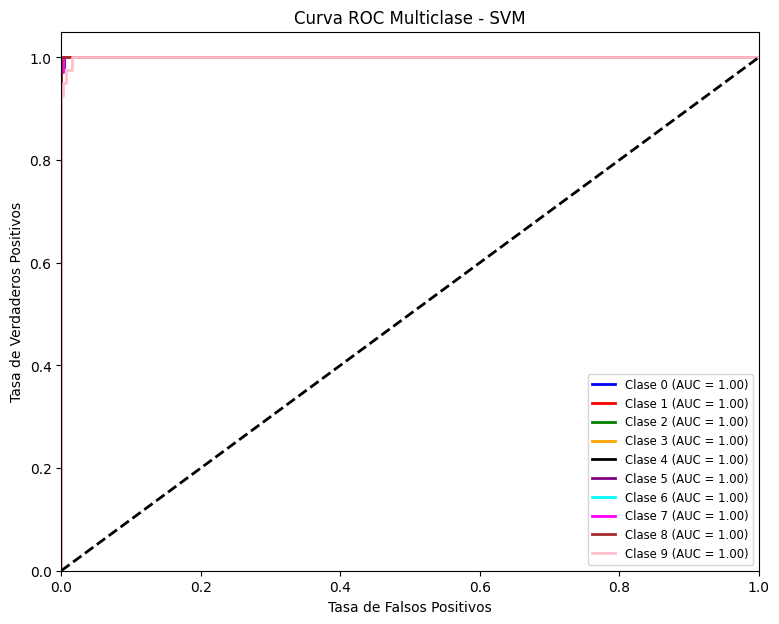

In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarizar las etiquetas para análisis multiclase
y_test_bin = label_binarize(y_test_clf, classes=np.unique(y_clf))
n_classes = y_test_bin.shape[1]

# Obtener probabilidades del modelo SVM (Mejor modelo)
model_svm = clf_models['Support Vector Machine']
y_score = model_svm.predict_proba(X_test_clf)

# Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar Curvas ROC
plt.figure(figsize=(9, 7))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'cyan', 'magenta', 'brown', 'pink'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Multiclase - SVM')
plt.legend(loc='lower right', fontsize='small')
plt.show()

### Ejercicio 5: Visualización de Resultados

Definimos y aplicamos la función para observar dónde acierta y dónde falla el modelo.

Muestras de predicciones CORRECTAS (Verde: Predicho, Azul: Real):


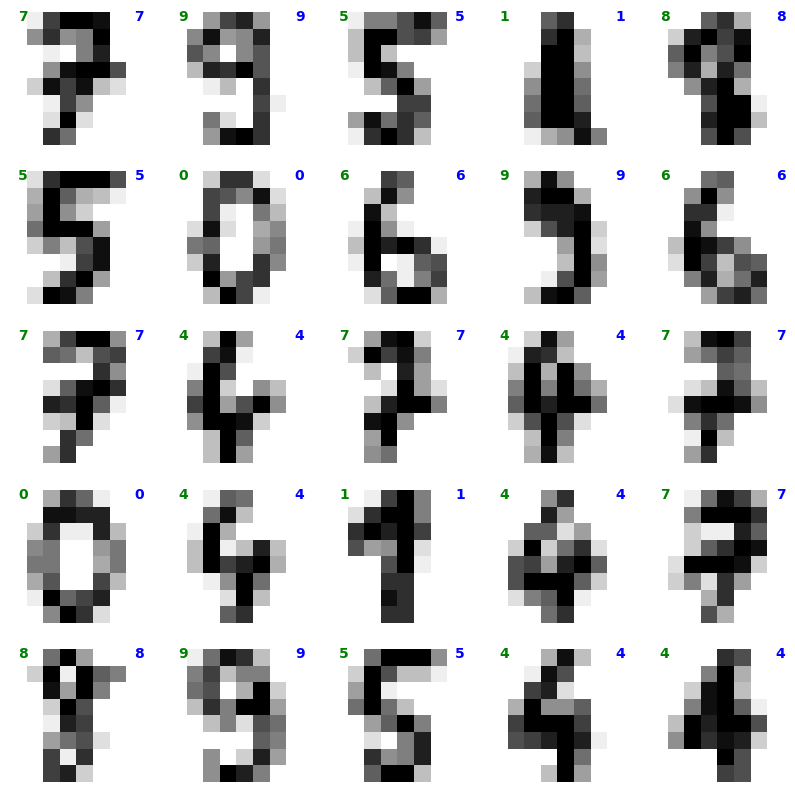


Muestras de predicciones INCORRECTAS (Rojo: Predicho, Azul: Real):


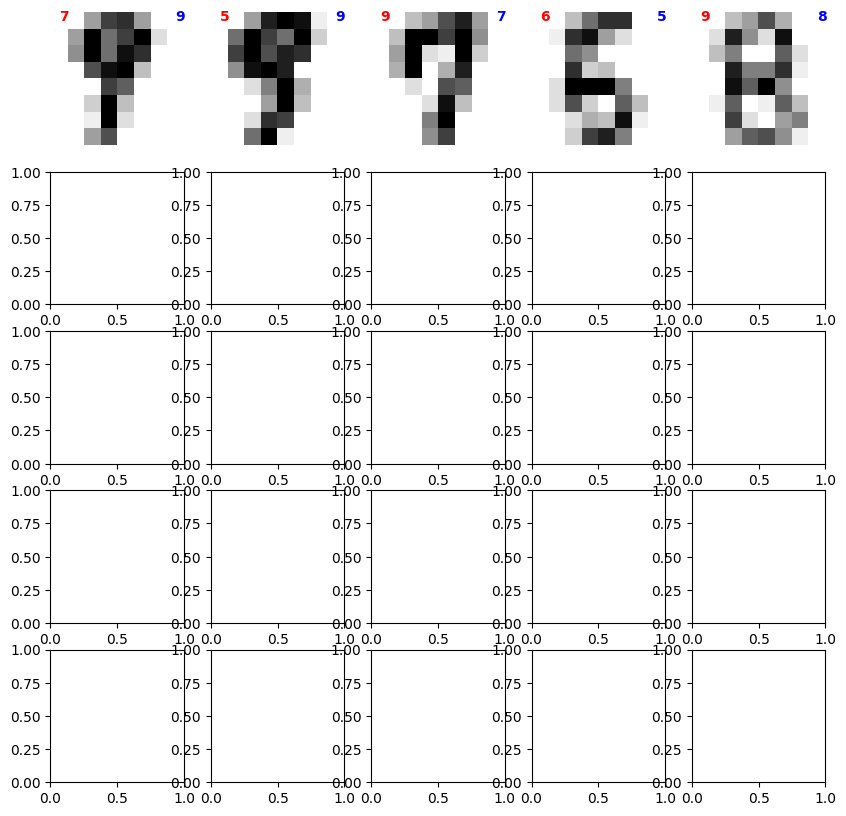

In [64]:
def mostrar_resultados(digits, model, nx=5, ny=5, label='correctos'):
    X = digits.drop(columns='target').values
    y = digits['target'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if label == 'correctos':
        mask = (y_pred == y_test)
        color = 'green'
    elif label == 'incorrectos':
        mask = (y_pred != y_test)
        color = 'red'

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    n_samples = min(nx * ny, len(X_aux))
    if n_samples == 0:
        print(f'No hay ejemplos para la etiqueta: {label}')
        return

    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(10, 10))
    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        row, col = divmod(i, ny)
        ax[row, col].imshow(data, cmap='gray_r')
        ax[row, col].text(0, 0, str(int(y_aux_pred[index])), color=color, weight='bold')
        ax[row, col].text(7, 0, str(int(y_aux_true[index])), color='blue', weight='bold')
        ax[row, col].axis('off')
    plt.show()

print('Muestras de predicciones CORRECTAS (Verde: Predicho, Azul: Real):')
mostrar_resultados(digits, SVC(probability=True), label='correctos')

print('\nMuestras de predicciones INCORRECTAS (Rojo: Predicho, Azul: Real):')
mostrar_resultados(digits, SVC(probability=True), label='incorrectos')

### Ejercicio 6: Conclusiones Finales

1. **Regresión**: El modelo **Random Forest** superó a la regresión lineal y KNN, demostrando que la relación entre variables como `MedInc` y el precio no es puramente lineal.
2. **Clasificación**: El modelo **SVM** alcanzó la mayor robustez (~98% accuracy). Las fallas (visibles en el Ejercicio 5) ocurren en trazos donde incluso para un humano el dígito es ambiguo.
3. **Procesamiento**: El escalado de datos fue crítico para el éxito de los modelos de distancias y márgenes.
4. **Veredicto**: Se recomienda el uso de modelos basados en ensambles para problemas tabulares (Regresión) y SVM o Redes Neuronales para problemas de visión sencillos (Clasificación).